# Interactive profile drawing

Draw bathymetric profiles by clicking directly on the map.

**Requirements:** install the notebook extras with `uv pip install -e ".[notebook]"`

In [1]:
%matplotlib widget

In [2]:
import bathy

## Load data

Load bathymetry from a local file or fetch a region from GEBCO.

In [4]:
# data = bathy.load_bathymetry("path/to/your/data.nc")
data = bathy.load_gebco_opendap(
    lon_range=(-12.08, -5.23),
    lat_range=(46.05, 49.54),
    save_path="../data/ne_atlantic_gebco.nc",
)

## Draw profiles

Call `draw_profile` to display the bathymetry map.

- **Left-click** to add waypoints along a profile path
- **Right-click** to finish the current profile and start a new one
- **Double-click** to stop drawing entirely

The profile plot on the right updates as you draw.

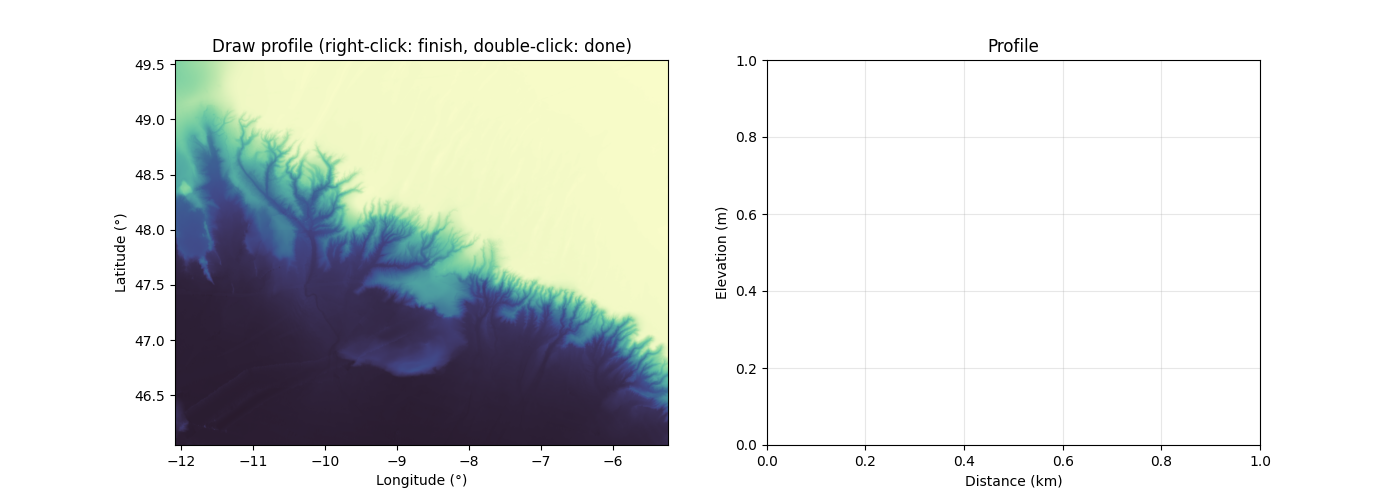

In [5]:
result = bathy.draw_profile(data)

## Access the profiles

After drawing, extracted profiles are available in `result["profiles"]`.

In [6]:
# All profiles
result["profiles"]

# First profile
profile = result["profiles"][0]
profile

Profile("Profile 1", 186.3 km, max_depth=-4376 m)

## Use with other functions

The drawn profiles work with all existing profile analysis and plotting functions.

(<Figure size 1200x500 with 1 Axes>,
 [<Axes: xlabel='Distance (km)', ylabel='Elevation (m)'>])

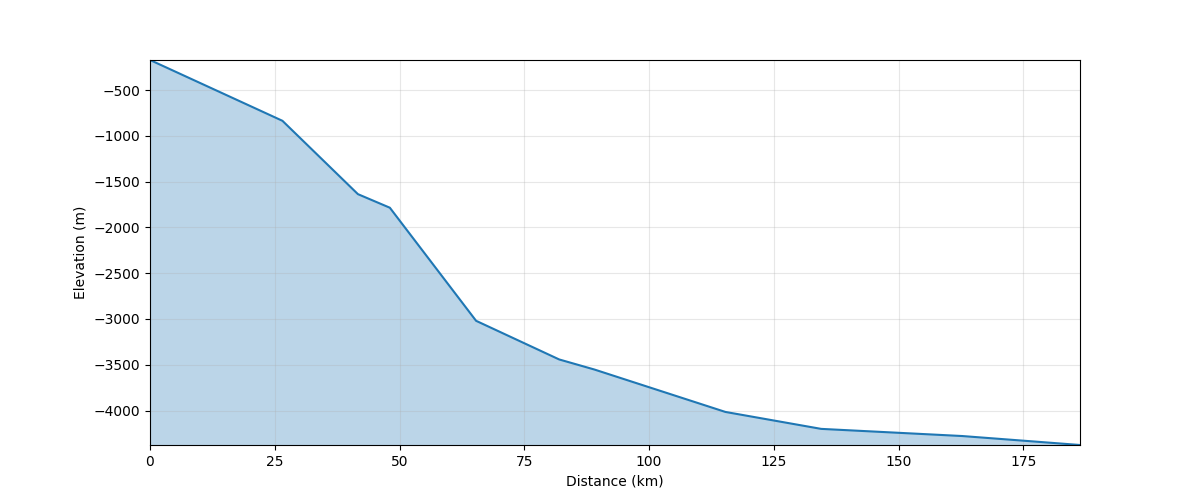

In [7]:
bathy.plot_profile(profile)

In [8]:
# Profile statistics
bathy.profile_stats(profile)

statistic,value
str,f64
"""total_distance""",186.341403
"""min_elevation""",-4376.0
"""max_elevation""",-172.0
"""mean_elevation""",-2846.636364
"""median_elevation""",-3442.0
"""std_elevation""",1422.325322
"""elevation_range""",4204.0


(<Figure size 1200x500 with 1 Axes>,
 [<Axes: xlabel='Distance (km)', ylabel='Elevation (m)'>])

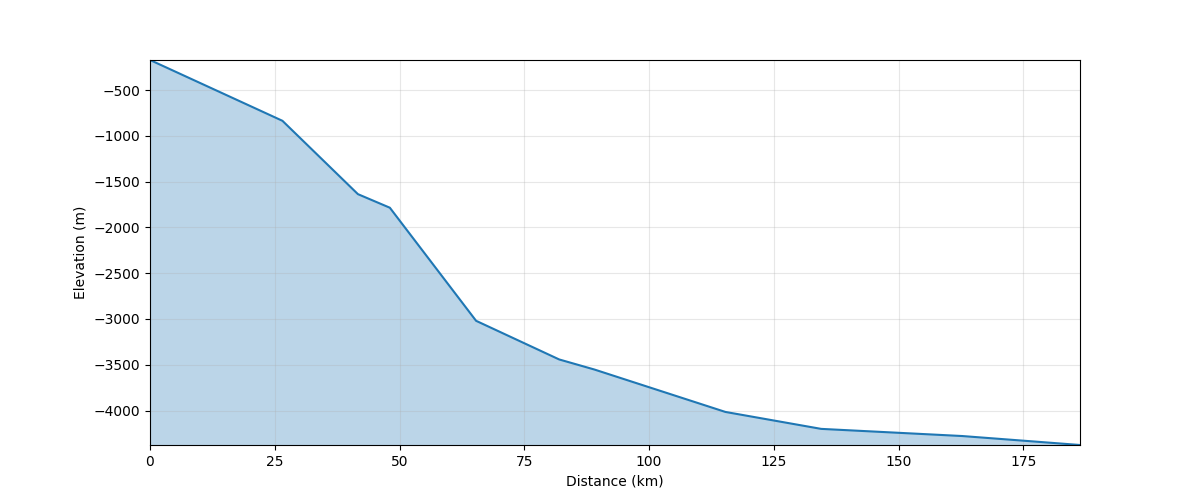

In [9]:
# Detect knickpoints
bathy.plot_knickpoints(profile)

In [11]:
# Export to GeoDataFrame
gdf = bathy.to_gdf(profile)
gdf

,name,total_distance_km,min_elevation_m,max_elevation_m,mean_elevation_m,geometry
0,Profile 1,186.341403,-4376.0,-172.0,-2846.636364,"LINESTRING (-10.006 48.89193, -9.95044 48.6561..."


(<Figure size 1200x600 with 1 Axes>,
 [<Axes: xlabel='Distance (km)', ylabel='Elevation (m)'>])

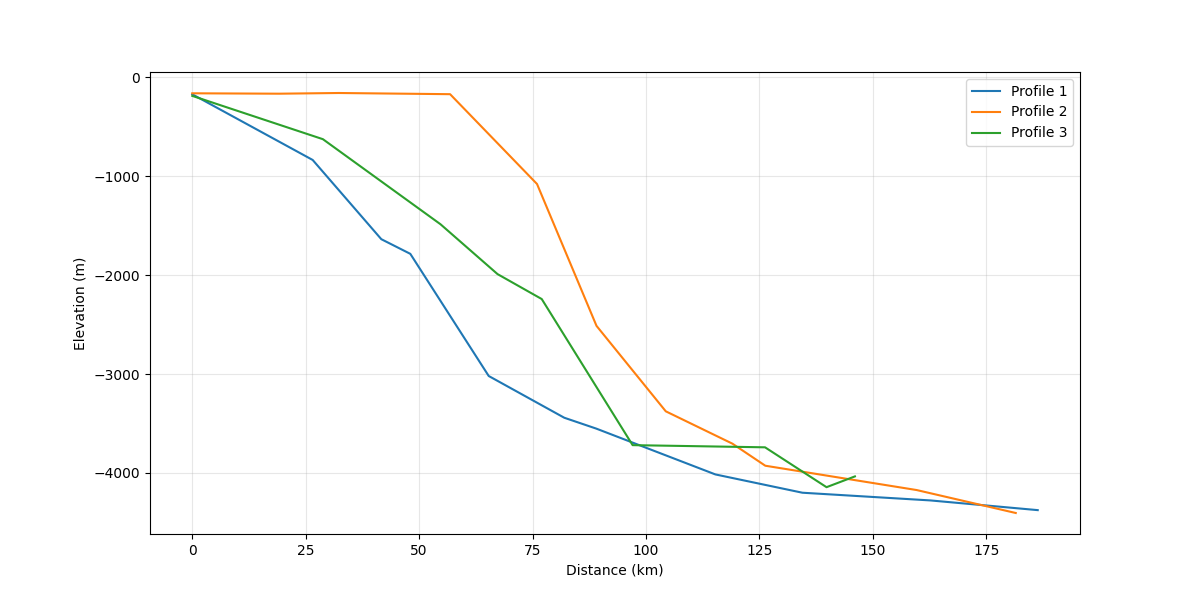

In [12]:
# Plot all drawn profiles together
bathy.plot_profiles(result["profiles"])